## SAM2 — Image Segmentation with Point / Box Prompts

## Task
1) GPU/디바이스 설정 -> 2) 패키지 설치 -> 3) 이미지 로드 -> 4) SAM2 로드/유틸 -> 5) Grounding DINO person 검출 -> 6) SAM2 사람별 마스크

### Grounding DINO
- 단체 사진에서 사람 후보를 빠르게 찾기 위해 사용합니다.
- 텍스트 라벨(`person`) 기반 zero-shot detection으로 사람 박스들을 반환합니다.

### SAM2
- 검출된 박스를 사람 단위의 정밀 마스크로 바꾸기 위해 사용합니다.
- Grounding DINO 박스를 프롬프트로 받아 픽셀 단위 세그먼트를 생성합니다.

### Depth Anything V2
- 각 사람의 상대적 거리(깊이)를 음높이 매핑 기준으로 쓰기 위해 사용합니다.
- 단일 이미지에서 depth map을 추정하고, 세그먼트 내부 평균 depth를 계산합니다.
    - 가까운 사람과, 먼 사람을 보고 가까운 사람을 높은 음(또는 낮은 음)으로 mapping

### QWEN3
- 사용자 프롬프트(예: 긴장감, 차분함)에 맞게 음악 순서/리듬을 조정하기 위해 사용합니다.
- 프롬프트를 JSON 파라미터(tempo, duration, recommended_order 등)로 변환해 MIDI/WAV 생성에 반영합니다.


In [1]:
import os

# torch import 전에 보이는 GPU를 물리 GPU 3번 하나로 제한
# 이후 파이썬 내부에서는 cuda:0 == 물리 GPU 3
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"사용 가능한 GPU 수(노출 기준): {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(i) / 1024**3
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  전체: {total:.1f}GB  |  예약: {reserved:.1f}GB")

DEVICE = "cuda:0"
torch.cuda.set_device(0)
print(f"\n사용 디바이스: {DEVICE} (물리 GPU 3)")

PyTorch 버전: 2.12.0.dev20260406+cu128
CUDA 사용 가능: True
사용 가능한 GPU 수(노출 기준): 1
  GPU 0: NVIDIA GeForce RTX 5090  |  전체: 31.4GB  |  예약: 0.0GB

사용 디바이스: cuda:0 (물리 GPU 3)


In [2]:
# 필수 패키지 설치 (최초 1회)
import importlib.util
import subprocess
import sys

def ensure_package(module_name: str, pip_target: str) -> None:
    if importlib.util.find_spec(module_name) is not None:
        print(f"[OK] {module_name} 이미 설치됨")
        return
    print(f"[INSTALL] {pip_target}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pip_target])

ensure_package("sam2", "git+https://github.com/facebookresearch/sam2.git")
ensure_package("transformers", "transformers")
ensure_package("pretty_midi", "pretty_midi")
print("\n설치 확인 완료")


[OK] sam2 이미 설치됨
[OK] transformers 이미 설치됨
[OK] pretty_midi 이미 설치됨

설치 확인 완료


발견된 이미지 파일: ['solvay.png']

[solvay.png]
원본 크기: 640 x 463
리사이즈 불필요


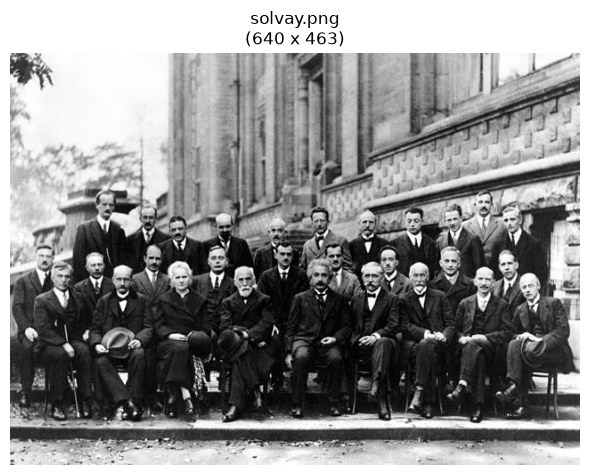

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMG_DIR  = "/home/mk/mk/workspace/dl/final/img" #이미지 저장 위치
MAX_SIZE = 1024

def load_and_resize(img_path: str) -> Image.Image:
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    print(f"원본 크기: {w} x {h}")
    if w > MAX_SIZE or h > MAX_SIZE:
        ratio = min(MAX_SIZE / w, MAX_SIZE / h)
        new_w, new_h = int(w * ratio), int(h * ratio)
        image = image.resize((new_w, new_h), Image.LANCZOS)
        print(f"리사이즈 후: {new_w} x {new_h}")
    else:
        print("리사이즈 불필요")
    return image

# img 디렉토리 내 이미지 파일 목록
img_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])
print(f"발견된 이미지 파일: {img_files}")

# 이미지 로드 및 미리보기
images = {}
fig, axes = plt.subplots(1, len(img_files), figsize=(6 * len(img_files), 5))
if len(img_files) == 1:
    axes = [axes]

for ax, fname in zip(axes, img_files):
    path = os.path.join(IMG_DIR, fname)
    print(f"\n[{fname}]")
    img = load_and_resize(path)
    images[fname] = img
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{fname}\n({img.width} x {img.height})")

plt.tight_layout()
plt.show()

In [4]:
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

MODEL_ID = "facebook/sam2.1-hiera-large"

predictor = SAM2ImagePredictor.from_pretrained(MODEL_ID, device=DEVICE)
print("SAM2ImagePredictor 로드 완료")

SAM2ImagePredictor 로드 완료


In [5]:
def _overlay_mask(ax, mask: np.ndarray, color: list, alpha: float = 0.45) -> None:
    """단일 마스크를 ax 위에 색상 오버레이로 그립니다."""
    h, w = mask.shape
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    overlay[mask > 0.5] = color + [alpha]
    ax.imshow(overlay)


def segment_with_points(
    image: Image.Image,
    point_coords: list,
    point_labels: list,
    multimask_output: bool = True,
) -> tuple:
    """
    포인트 프롬프트로 세그멘테이션을 수행합니다.

    Args:
        image          : PIL Image
        point_coords   : [[x, y], ...] 형태의 포인트 좌표 목록
        point_labels   : [1 또는 0, ...] (1=전경, 0=배경)
        multimask_output: True면 3개 마스크 후보 반환

    Returns:
        masks (N, H, W), scores (N,), logits (N, H, W)
    """
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        predictor.set_image(np.array(image))
        masks, scores, logits = predictor.predict(
            point_coords=np.array(point_coords),
            point_labels=np.array(point_labels),
            multimask_output=multimask_output,
        )
    order = np.argsort(scores)[::-1]
    return masks[order], scores[order], logits[order]


def segment_with_box(
    image: Image.Image,
    box: list,
) -> tuple:
    """
    박스 프롬프트로 세그멘테이션을 수행합니다.

    Args:
        image: PIL Image
        box  : [x0, y0, x1, y1] 픽셀 좌표

    Returns:
        masks (N, H, W), scores (N,), logits (N, H, W)
    """
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        predictor.set_image(np.array(image))
        masks, scores, logits = predictor.predict(
            box=np.array(box),
            multimask_output=False,
        )
    return masks, scores, logits


def visualize_masks(
    image: Image.Image,
    masks: np.ndarray,
    scores: np.ndarray,
    point_coords: list = None,
    point_labels: list = None,
    box: list = None,
    title: str = "",
) -> None:
    """마스크 결과를 이미지 위에 오버레이로 시각화합니다."""
    cmap   = plt.colormaps.get_cmap("tab10")
    n      = len(masks)
    ncols  = min(n, 3)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (ax, mask, score) in enumerate(zip(axes, masks, scores)):
        color = list(cmap(i % 10))[:3]
        ax.imshow(image)
        _overlay_mask(ax, mask, color)

        # 포인트 표시
        if point_coords is not None:
            for (x, y), lbl in zip(point_coords, point_labels):
                marker_color = "lime" if lbl == 1 else "red"
                ax.scatter(x, y, s=120, c=marker_color, edgecolors="white", linewidths=1.5, zorder=5)

        # 박스 표시
        if box is not None:
            x0, y0, x1, y1 = box
            rect = patches.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                linewidth=2, edgecolor="yellow", facecolor="none",
            )
            ax.add_patch(rect)

        ax.set_title(f"Mask {i+1}  score={score:.3f}")
        ax.axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

### Grounding DINO: 사람 박스 검출


In [ ]:
# Grounding DINO(다중 person box) -> SAM2(개별 mask) 안정화 버전
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


def expand_box_xyxy(box, W, H, scale=0.06):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    dx, dy = bw * scale, bh * scale
    nx1 = int(max(0, x1 - dx))
    ny1 = int(max(0, y1 - dy))
    nx2 = int(min(W - 1, x2 + dx))
    ny2 = int(min(H - 1, y2 + dy))
    return [nx1, ny1, nx2, ny2]


def nms_xyxy_np(boxes, scores, iou_thr=0.45):
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1 + 1)
        h = np.maximum(0.0, yy2 - yy1 + 1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-8)

        inds = np.where(iou < iou_thr)[0]
        order = order[inds + 1]

    return keep


# 1) 입력 이미지
TARGET_IMAGE = "solvay.png"
image = images[TARGET_IMAGE]
img_np = np.array(image)
H, W = img_np.shape[:2]

# 2) Grounding DINO 로드
gdino_model_id = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(gdino_model_id)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(gdino_model_id).to(DEVICE)
dino_model.eval()

# 라벨 프롬프트를 넓게 줘서 흑백 단체사진에서도 사람 recall 향상
text_prompt = "person . man . woman . human . gentleman ."

inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    outputs = dino_model(**inputs)

# 3) threshold 자동 완화 (검출 너무 적으면 낮춤)
# transformers 버전에 따라 인자가 다릅니다.
# - 신버전: box_threshold
# - 구버전: threshold
threshold_schedule = [0.30, 0.25, 0.20, 0.15, 0.10]
raw_boxes, raw_scores = None, None


def postprocess_grounding(outputs, input_ids, thr, target_sizes, text_thr=0.20):
    try:
        # new API
        return processor.post_process_grounded_object_detection(
            outputs,
            input_ids,
            box_threshold=thr,
            text_threshold=text_thr,
            target_sizes=target_sizes,
        )
    except TypeError:
        # old API
        return processor.post_process_grounded_object_detection(
            outputs,
            input_ids,
            threshold=thr,
            target_sizes=target_sizes,
        )


for thr in threshold_schedule:
    res = postprocess_grounding(
        outputs,
        inputs.input_ids,
        thr,
        target_sizes=[(H, W)],
        text_thr=0.20,
    )[0]

    boxes = res["boxes"].detach().cpu().numpy().tolist()
    scores = res["scores"].detach().cpu().numpy().tolist()

    # 너무 작은 박스 제거
    min_area = int(H * W * 0.0006)
    f_boxes, f_scores = [], []
    for b, s in zip(boxes, scores):
        x1, y1, x2, y2 = map(int, b)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W - 1, x2), min(H - 1, y2)
        area = max(0, x2 - x1) * max(0, y2 - y1)
        if area >= min_area:
            f_boxes.append([x1, y1, x2, y2])
            f_scores.append(float(s))

    print(f"thr={thr:.2f} -> filtered boxes={len(f_boxes)}")

    raw_boxes, raw_scores = f_boxes, f_scores
    if len(f_boxes) >= 12:
        break

if not raw_boxes:
    raise RuntimeError("사람 박스를 찾지 못했습니다. threshold/text_prompt를 조정하세요.")


keep_idx = nms_xyxy_np(raw_boxes, raw_scores, iou_thr=0.45)
boxes_nms = [raw_boxes[i] for i in keep_idx]
scores_nms = [raw_scores[i] for i in keep_idx]

print(f"NMS 후 박스 수: {len(boxes_nms)}")


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

thr=0.30 -> filtered boxes=52
NMS 후 박스 수: 30


### SAM2: 박스 기반 사람별 마스크 분할


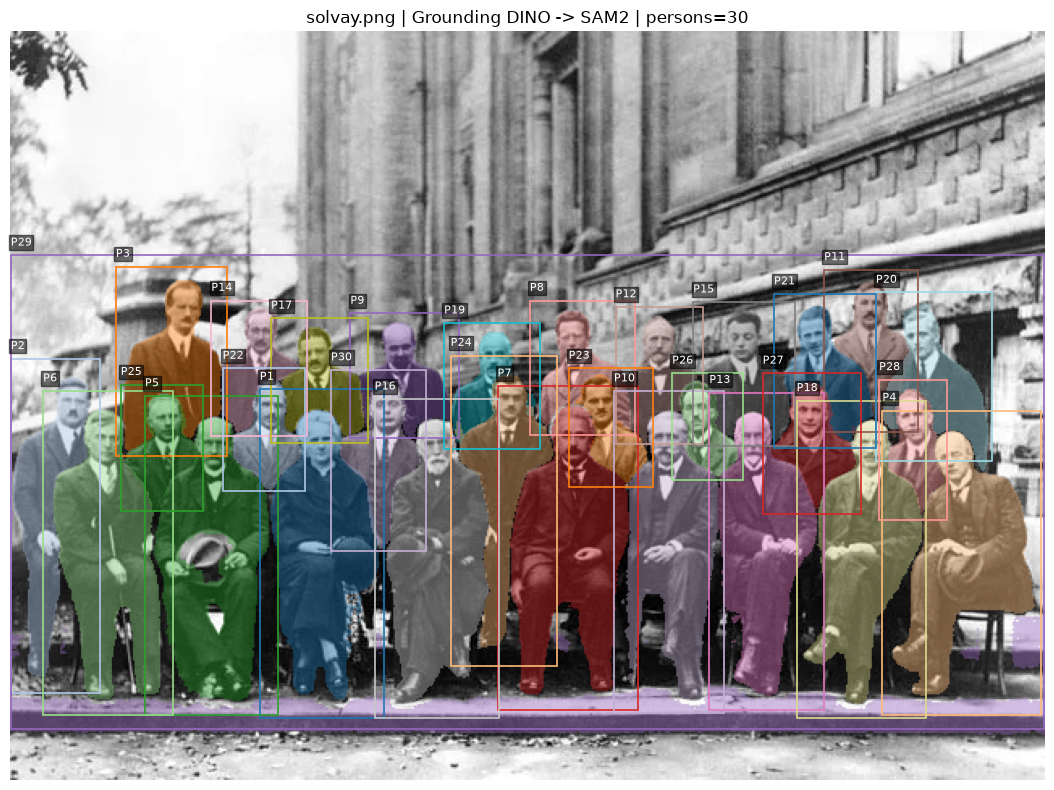


[사람별 마스크 요약]
P01 | det=0.596 | sam=0.898 | box=[154, 221, 231, 424] | area=7832
P02 | det=0.495 | sam=0.926 | box=[0, 202, 55, 409] | area=4030
P03 | det=0.485 | sam=0.941 | box=[65, 145, 134, 262] | area=3639
P04 | det=0.474 | sam=0.922 | box=[539, 234, 637, 422] | area=7367
P05 | det=0.473 | sam=0.879 | box=[83, 225, 165, 422] | area=8019
P06 | det=0.468 | sam=0.910 | box=[20, 222, 100, 422] | area=7703
P07 | det=0.466 | sam=0.918 | box=[301, 219, 388, 419] | area=8451
P08 | det=0.466 | sam=0.902 | box=[321, 166, 386, 249] | area=1896
P09 | det=0.465 | sam=0.906 | box=[210, 174, 277, 251] | area=1864
P10 | det=0.464 | sam=0.879 | box=[373, 222, 441, 421] | area=6749
P11 | det=0.463 | sam=0.879 | box=[503, 147, 561, 247] | area=2162
P12 | det=0.457 | sam=0.922 | box=[374, 170, 428, 255] | area=1765
P13 | det=0.456 | sam=0.902 | box=[432, 223, 503, 419] | area=6738
P14 | det=0.456 | sam=0.891 | box=[124, 166, 183, 250] | area=1772
P15 | det=0.452 | sam=0.930 | box=[422, 167, 485, 256]

In [7]:
# 5) SAM2로 사람별 마스크
person_masks = []
for box, det_score in zip(boxes_nms, scores_nms):
    box_expanded = expand_box_xyxy(box, W, H, scale=0.06)
    masks, sam_scores, _ = segment_with_box(image, box_expanded)

    mask = masks[0] if masks.ndim == 3 else masks
    person_masks.append({
        "box": box_expanded,
        "det_score": float(det_score),
        "sam_score": float(sam_scores[0]) if np.ndim(sam_scores) else float(sam_scores),
        "mask": mask.astype(bool),
    })

# 6) 시각화
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image)
ax.axis("off")
ax.set_title(f"{TARGET_IMAGE} | Grounding DINO -> SAM2 | persons={len(person_masks)}")

cmap = plt.colormaps.get_cmap("tab20")
for i, p in enumerate(person_masks):
    color = list(cmap(i % 20))[:3]
    _overlay_mask(ax, p["mask"], color, alpha=0.42)

    x1, y1, x2, y2 = p["box"]
    ax.add_patch(
        patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.2, edgecolor=color, facecolor="none")
    )
    ax.text(
        x1,
        max(0, y1 - 6),
        f"P{i+1}",
        fontsize=8,
        color="white",
        bbox=dict(facecolor="black", alpha=0.55, pad=1.2),
    )

plt.tight_layout()
plt.show()

print("\n[사람별 마스크 요약]")
for i, p in enumerate(person_masks, start=1):
    print(
        f"P{i:02d} | det={p['det_score']:.3f} | sam={p['sam_score']:.3f} | "
        f"box={p['box']} | area={int(p['mask'].sum())}"
    )

# 후속 depth->MIDI 셀에서 재사용
person_segments = person_masks


### SAM2 세그먼트 + Depth Anything V2 + BLIP 캡셔닝 + MIDI 생성

- `chat_img`(대화형 선택 이미지)가 있으면 우선 사용하고, 없으면 `selected_image`를 사용합니다.
- SAM2 자동 마스크로 객체/인물 후보를 얻고, Depth Anything V2로 depth map을 생성합니다.
- 각 세그먼트 평균 depth를 계산해 앞열부터(가까운 순) 1옥타브 시작 음계로 매핑합니다.
- BLIP 캡션을 함께 붙여 결과를 해석하기 쉽게 만들고, 최종 MIDI 파일을 저장합니다.

타겟 이미지: solvay.png (640 x 463)
person_segments 입력 수: 30
사람 세그먼트 수(필터 후): 29


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

MIDI 저장 완료: outputs/solvay_depth_segments.mid


/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1211762/350397146.py:239: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu

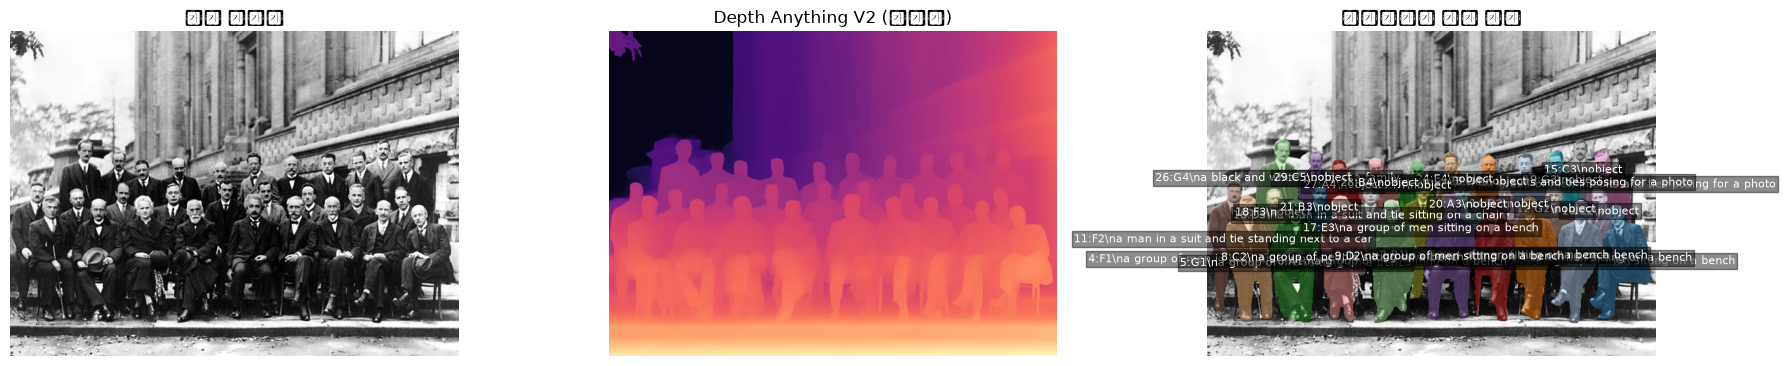


[세그먼트 -> 음계 매핑 결과]
01. note=  C1 (24) | depth=0.714 | area=  7367 | caption=a group of men sitting on a bench
02. note=  D1 (26) | depth=0.673 | area=  6739 | caption=a group of men sitting on a bench
03. note=  E1 (28) | depth=0.653 | area=  6738 | caption=a group of men sitting on a bench
04. note=  F1 (29) | depth=0.647 | area=  7703 | caption=a group of men in suits and ties posing for a photo
05. note=  G1 (31) | depth=0.645 | area=  8019 | caption=a group of men sitting on a bench
06. note=  A1 (33) | depth=0.645 | area=  7956 | caption=a group of men sitting on a bench
07. note=  B1 (35) | depth=0.645 | area=  6749 | caption=a group of men sitting on a bench
08. note=  C2 (36) | depth=0.636 | area=  7832 | caption=a group of people sitting on a bench
09. note=  D2 (38) | depth=0.636 | area=  8451 | caption=a group of men sitting on a bench
10. note=  E2 (40) | depth=0.611 | area=  1554 | caption=object
11. note=  F2 (41) | depth=0.584 | area=  4030 | caption=a man in a suit and

In [8]:
from pathlib import Path

try:
    from transformers import pipeline, BlipProcessor, BlipForConditionalGeneration
except ImportError as e:
    raise ImportError("transformers가 필요합니다. 예) pip install transformers") from e

try:
    import pretty_midi
except ImportError as e:
    raise ImportError("pretty_midi가 필요합니다. 예) pip install pretty_midi") from e


# ------------------------------------------------------------
# 0) 입력 이미지 선택
# ------------------------------------------------------------
if "chat_img" in globals() and "chat_fname" in globals():
    target_img = chat_img
    target_name = chat_fname
elif "selected_image" in globals() and "TARGET_IMAGE" in globals():
    target_img = selected_image
    target_name = TARGET_IMAGE
else:
    target_name = img_files[0]
    target_img = images[target_name]

print(f"타겟 이미지: {target_name} ({target_img.width} x {target_img.height})")
img_np = np.array(target_img)


# ------------------------------------------------------------
# 1) 세그먼트 준비 (PERSON-ONLY)
#    - 반드시 Grounding DINO -> SAM2에서 만든 person_segments만 사용
# ------------------------------------------------------------
segments = []

if "person_segments" not in globals() or len(person_segments) == 0:
    raise RuntimeError(
        "person_segments가 없습니다. 먼저 'Grounding DINO -> SAM2' 셀을 실행해 사람 마스크를 생성하세요."
    )

PERSON_DET_SCORE_MIN = 0.25
PERSON_SAM_SCORE_MIN = 0.50
PERSON_MIN_MASK_AREA_RATIO = 0.0008
person_min_area = int(img_np.shape[0] * img_np.shape[1] * PERSON_MIN_MASK_AREA_RATIO)

raw_person_count = len(person_segments)

for p in person_segments:
    det_ok = p.get("det_score", 1.0) >= PERSON_DET_SCORE_MIN
    sam_ok = p.get("sam_score", 1.0) >= PERSON_SAM_SCORE_MIN
    if not (det_ok and sam_ok):
        continue

    mask = p["mask"].astype(bool)
    area = int(mask.sum())
    if area < person_min_area:
        continue

    ys, xs = np.where(mask)
    y0, y1 = int(ys.min()), int(ys.max())
    x0, x1 = int(xs.min()), int(xs.max())

    crop = img_np[y0:y1 + 1, x0:x1 + 1]
    cx = float(xs.mean())
    cy = float(ys.mean())

    segments.append({
        "mask": mask,
        "area": area,
        "bbox": [x0, y0, x1, y1],
        "crop": crop,
        "center": (cx, cy),
        "det_score": float(p.get("det_score", 1.0)),
        "sam_score": float(p.get("sam_score", 1.0)),
    })

if not segments:
    raise RuntimeError(
        "person_segments는 있지만 필터 후 남은 사람이 없습니다. score/area 임계값을 낮춰보세요."
    )

print(f"person_segments 입력 수: {raw_person_count}")
print(f"사람 세그먼트 수(필터 후): {len(segments)}")


# ------------------------------------------------------------
# 2) Depth Anything V2로 depth map 생성
# ------------------------------------------------------------
def _hf_device(device_str: str) -> int:
    if isinstance(device_str, str) and device_str.startswith("cuda"):
        if ":" in device_str:
            return int(device_str.split(":", 1)[1])
        return 0
    return -1

hf_device = _hf_device(DEVICE)

depth_pipe = pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=hf_device,
)

depth_pred = depth_pipe(target_img)
depth_map = np.array(depth_pred["depth"]).astype(np.float32)

depth_norm = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min() + 1e-8)


# ------------------------------------------------------------
# 3) BLIP 캡션 생성 (세그먼트별)
# ------------------------------------------------------------
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)
blip_model.eval()

max_caption_segments = 15  # 너무 많으면 데모가 느려질 수 있어 상위 일부만 캡션
segments_for_caption = sorted(segments, key=lambda s: s["area"], reverse=True)[:max_caption_segments]

for seg in segments_for_caption:
    crop_img = Image.fromarray(seg["crop"])
    inputs = blip_processor(images=crop_img, return_tensors="pt").to(DEVICE)
    with torch.inference_mode():
        out_ids = blip_model.generate(**inputs, max_new_tokens=20)
    caption = blip_processor.decode(out_ids[0], skip_special_tokens=True).strip()
    seg["caption"] = caption if caption else "object"

for seg in segments:
    if "caption" not in seg:
        seg["caption"] = "object"


# ------------------------------------------------------------
# 4) depth 기반 음계 매핑 (중복 없는 유일 note 할당)
# ------------------------------------------------------------
for seg in segments:
    seg["mean_depth"] = float(depth_norm[seg["mask"]].mean())

# Depth Anything 출력에서 "가까움" 방향이 다를 수 있어 토글 제공
NEAR_IS_HIGH_DEPTH_VALUE = True

if NEAR_IS_HIGH_DEPTH_VALUE:
    ordered = sorted(segments, key=lambda s: (-s["mean_depth"], s["center"][0]))
else:
    ordered = sorted(segments, key=lambda s: (s["mean_depth"], s["center"][0]))

# C major 음계 후보를 넓은 옥타브에서 만들고, 앞열부터 유일하게 배정
major_scale = [0, 2, 4, 5, 7, 9, 11]  # C Major
min_note, max_note = 24, 96
start_oct, end_oct = 2, 7

scale_candidates = []
for octv in range(start_oct, end_oct + 1):
    for pc in major_scale:
        n = 12 * octv + pc
        if min_note <= n <= max_note:
            scale_candidates.append(n)

scale_candidates = sorted(set(scale_candidates))

# 세그먼트 수가 후보보다 많으면 chromatic 후보를 추가해 유일성 유지
if len(ordered) > len(scale_candidates):
    chromatic = list(range(min_note, max_note + 1))
    extra = [n for n in chromatic if n not in scale_candidates]
    note_candidates = scale_candidates + extra
else:
    note_candidates = scale_candidates

for idx, seg in enumerate(ordered):
    midi_note = int(note_candidates[idx])
    seg["midi_note"] = midi_note
    seg["note_name"] = pretty_midi.note_number_to_name(midi_note)


# ------------------------------------------------------------
# 5) MIDI 파일 생성
# ------------------------------------------------------------
out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)

midi_path = out_dir / f"{Path(target_name).stem}_depth_segments.mid"
pm = pretty_midi.PrettyMIDI(initial_tempo=100)
piano = pretty_midi.Instrument(program=0, name="DepthPiano")

start_t = 0.0
dur = 0.55
gap = 0.05

for seg in ordered:
    velocity = int(np.clip(50 + seg["area"] / 3000, 50, 110))
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=seg["midi_note"],
        start=start_t,
        end=start_t + dur,
    )
    piano.notes.append(note)
    start_t += dur + gap

pm.instruments.append(piano)
pm.write(str(midi_path))
print(f"MIDI 저장 완료: {midi_path}")


# ------------------------------------------------------------
# 6) 시각화: 원본 / depth / 마스크+음계
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(target_img)
axes[0].set_title("원본 이미지")
axes[0].axis("off")

axes[1].imshow(depth_norm, cmap="magma")
axes[1].set_title("Depth Anything V2 (정규화)")
axes[1].axis("off")

axes[2].imshow(target_img)
axes[2].set_title("세그먼트별 음계 매핑")
axes[2].axis("off")

cmap = plt.colormaps.get_cmap("tab20")
for i, seg in enumerate(ordered):
    color = list(cmap(i % 20))[:3]
    _overlay_mask(axes[2], seg["mask"], color, alpha=0.45)
    cx, cy = seg["center"]
    axes[2].text(
        cx,
        cy,
        f"{i+1}:{seg['note_name']}\\n{seg['caption']}",
        color="white",
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="black", alpha=0.45, pad=1.5),
    )

plt.tight_layout()
plt.show()

print("\n[세그먼트 -> 음계 매핑 결과]")
for i, seg in enumerate(ordered, start=1):
    print(
        f"{i:02d}. note={seg['note_name']:>4} ({seg['midi_note']:>2}) | "
        f"depth={seg['mean_depth']:.3f} | area={seg['area']:>6} | caption={seg['caption']}"
    )


### Interactive

- 이미지에서 사람 세그먼트를 클릭하면 해당 세그먼트의 음을 즉시 재생합니다.
- `ordered`(depth->음계 매핑 결과)가 먼저 준비되어 있어야 합니다.
- 클릭 이벤트가 안 잡히면 이 셀에서 자동으로 `%matplotlib widget`을 시도합니다.

'선택: P6 | A1 (33) | depth=0.645'

인터랙티브 클릭 핸들러 연결 완료 (id=16)


/home/mk/anaconda3/envs/mk_dl/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/mk/anaconda3/envs/mk_dl/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 47533 (\N{HANGUL SYLLABLE RIG}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/mk/anaconda3/envs/mk_dl/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/mk/anaconda3/envs/mk_dl/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/mk/anaconda3/envs/mk_dl/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392:

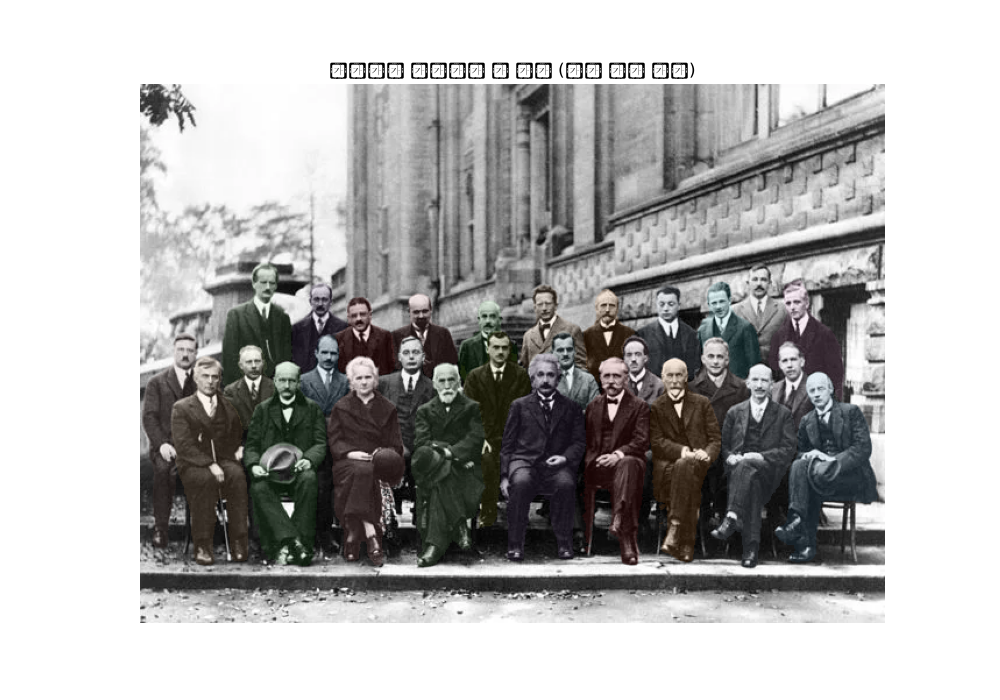

In [ ]:
# 이미지 클릭 -> 세그먼트 음 재생 인터랙티브 셀
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display, clear_output

try:
    import pretty_midi
except ImportError as e:
    raise ImportError("pretty_midi가 필요합니다. 예) pip install pretty_midi") from e

if "ordered" not in globals() or len(ordered) == 0:
    raise RuntimeError("먼저 depth->음계 매핑 셀을 실행해 ordered를 준비하세요.")

# 클릭 이벤트를 위해 widget backend 시도
try:
    ip = get_ipython()  # noqa: F821
    if ip is not None:
        ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

if "target_img" in globals():
    click_img = target_img
elif "images" in globals() and "img_files" in globals() and len(img_files) > 0:
    click_img = images[img_files[0]]
else:
    raise RuntimeError("클릭할 이미지가 없습니다. 이미지 로드 셀부터 실행하세요.")

img_np = np.array(click_img.convert("RGB"))

# 오디오 합성 파라미터
SR = 44100
CLICK_NOTE_SEC = 0.45


def midi_to_freq(note_num: int) -> float:
    return 440.0 * (2.0 ** ((note_num - 69) / 12.0))


def synth_one_note(midi_note: int, duration: float = CLICK_NOTE_SEC, sr: int = SR) -> np.ndarray:
    n_samples = int(sr * duration)
    t = np.arange(n_samples, dtype=np.float32) / sr
    f = midi_to_freq(int(midi_note))
    wave_data = 0.35 * np.sin(2 * np.pi * f * t)

    # 간단한 ADSR 느낌의 envelope
    att = max(1, int(0.08 * n_samples))
    rel = max(1, int(0.18 * n_samples))
    env = np.ones(n_samples, dtype=np.float32)
    env[:att] = np.linspace(0, 1, att, dtype=np.float32)
    env[-rel:] = np.linspace(1, 0, rel, dtype=np.float32)
    return (wave_data * env).astype(np.float32)


# 빠른 재생을 위해 미리 오디오 캐시
note_audio_cache = {}
for seg in ordered:
    midi_note = int(seg["midi_note"])
    if midi_note not in note_audio_cache:
        note_audio_cache[midi_note] = synth_one_note(midi_note)

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(click_img)
ax.set_title("클릭해서 세그먼트 음 재생 (사람 영역 클릭)")
ax.axis("off")

# 시각 가이드(희미한 전체 마스크)
cmap = plt.colormaps.get_cmap("tab20")
for i, seg in enumerate(ordered):
    _overlay_mask(ax, seg["mask"], list(cmap(i % 20))[:3], alpha=0.12)

status = display("세그먼트를 클릭하세요.", display_id=True)
audio_out = display("", display_id=True)


def pick_segment_at(x: int, y: int):
    hits = []
    for idx, seg in enumerate(ordered, start=1):
        mask = seg["mask"]
        if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1] and bool(mask[y, x]):
            hits.append((idx, seg))

    if hits:
        # 여러 마스크가 겹치면 더 작은 영역(더 구체적 인스턴스) 우선
        hits = sorted(hits, key=lambda item: item[1]["area"])
        return hits[0]

    # 마스크 밖을 클릭하면 최근접 중심점 세그먼트 선택
    best = None
    best_d2 = float("inf")
    for idx, seg in enumerate(ordered, start=1):
        cx, cy = seg["center"]
        d2 = (cx - x) ** 2 + (cy - y) ** 2
        if d2 < best_d2:
            best_d2 = d2
            best = (idx, seg)
    return best


def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return

    x, y = int(event.xdata), int(event.ydata)
    idx, seg = pick_segment_at(x, y)

    midi_note = int(seg["midi_note"])
    note_name = seg.get("note_name", pretty_midi.note_number_to_name(midi_note))
    caption = seg.get("caption", "object")

    # 클릭 포인트 표시
    ax.plot([x], [y], marker="o", markersize=8, color="yellow")
    ax.set_title(f"P{idx} | {note_name} ({midi_note}) | {caption}")
    fig.canvas.draw_idle()

    status.update(f"선택: P{idx} | {note_name} ({midi_note}) | depth={seg.get('mean_depth', -1):.3f}")

    # LEGACY (주석 보존): 출력 전체를 지우면 인터랙션이 끊길 수 있음
    # audio = note_audio_cache[midi_note]
    # clear_output(wait=True)
    # display(fig)
    # display(status)
    # display(Audio(audio, rate=SR, autoplay=True))

    audio = note_audio_cache[midi_note]
    audio_out.update(Audio(audio, rate=SR, autoplay=True))


cid = fig.canvas.mpl_connect("button_press_event", on_click)
print(f"인터랙티브 클릭 핸들러 연결 완료 (id={cid})")
plt.show()


### QWEN3 추천 + 10초 WAV + 세그먼트 하이라이트 비디오 저장

- 출력 오디오는 약 10초로 맞춥니다.
- 같은 타임라인으로 `P` 세그먼트가 눌리는 과정을 MP4로 저장합니다.
- 파일: `outputs/qwen_<name>.mid`, `outputs/qwen_<name>.wav`, `outputs/qwen_<name>_segments.mp4`

In [10]:
# # LEGACY 셀 (보존용)
# # - 사용자 프롬프트 반영이 약해 새 셀로 대체됨
# # - 아래 코드는 참고용으로 남기고 실행은 차단합니다.
# raise RuntimeError("LEGACY QWEN 셀입니다. 바로 아래 'QWEN Prompt-Aligned v2' 셀을 실행하세요.")

# import json
# import math
# import re
# import wave
# from pathlib import Path

# import numpy as np
# import torch
# from PIL import Image

# try:
#     from transformers import pipeline
# except ImportError as e:
#     raise ImportError("transformers가 필요합니다. 예) pip install transformers") from e

# try:
#     import pretty_midi
# except ImportError as e:
#     raise ImportError("pretty_midi가 필요합니다. 예) pip install pretty_midi") from e

# # opencv는 비디오 저장에 필요
# try:
#     import cv2
# except ImportError:
#     import subprocess
#     import sys

#     subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless"])
#     import cv2


# if "ordered" not in globals() or len(ordered) == 0:
#     raise RuntimeError("먼저 depth->음계 매핑 셀을 실행해 ordered 세그먼트를 준비하세요.")

# if "target_img" in globals():
#     render_img = target_img
# elif "images" in globals() and "img_files" in globals() and len(img_files) > 0:
#     render_img = images[img_files[0]]
# else:
#     raise RuntimeError("렌더링할 이미지가 없습니다. 이미지 로드 셀부터 실행하세요.")

# segment_note_map = {}
# for i, seg in enumerate(ordered, start=1):
#     if "midi_note" in seg:
#         segment_note_map[f"P{i}"] = int(seg["midi_note"])

# if not segment_note_map:
#     raise RuntimeError("P-노트 매핑이 비어 있습니다. depth 매핑 셀을 다시 실행하세요.")

# print(f"사용 가능한 세그먼트 수: {len(segment_note_map)}")
# print("예시 토큰:", ", ".join(list(segment_note_map.keys())[:10]))

# USER_SEQUENCE = input("시퀀스 입력 (예: P1-P2-P6, 비우면 모델 추천): ").strip()
# MUSIC_PROMPT = input("음악 프롬프트 입력 (예: 비행기, 긴장감 있는 분위기): ").strip()
# if not USER_SEQUENCE:
#     USER_SEQUENCE = ""
# if not MUSIC_PROMPT:
#     MUSIC_PROMPT = "neutral piano"

# TARGET_AUDIO_SEC = 10.0
# GAP_RATIO = 0.15
# MIN_EVENTS = 8
# FPS = 12


# # ------------------------------------------------------------
# # 1) QWEN으로 음악 파라미터 + 추천 순서 생성
# # ------------------------------------------------------------
# # LEGACY (주석 보존): QWEN3 단일 모델만 사용
# # QWEN_MODEL_CANDIDATES = [
# #     "Qwen/Qwen3-8B"
# # ]

# QWEN_MODEL_CANDIDATES = [
#     "Qwen/Qwen3-8B",
#     # "Qwen/Qwen2.5-0.5B-Instruct",
# ]


# def _extract_first_json_block(text: str):
#     start = text.find("{")
#     if start < 0:
#         return None
#     depth = 0
#     for i in range(start, len(text)):
#         ch = text[i]
#         if ch == "{":
#             depth += 1
#         elif ch == "}":
#             depth -= 1
#             if depth == 0:
#                 return text[start : i + 1]
#     return None


# system_prompt = "You are a music arrangement assistant. Return strict JSON only."
# user_prompt = f"""
# user_sequence: {USER_SEQUENCE if USER_SEQUENCE else '<empty>'}
# music_prompt: {MUSIC_PROMPT}
# available_tokens: {list(segment_note_map.keys())[:40]}
# Return JSON keys:
# - tempo: integer 70..160
# - velocity: integer 50..110
# - duration: float 0.15..1.20
# - transpose: integer -12..12
# - repeat: integer 1..4
# - recommended_order: array of token strings like ["P1","P3","P2"]
# JSON only.
# """.strip()

# params = None
# used_model = None
# hf_device = 0 if isinstance(DEVICE, str) and DEVICE.startswith("cuda") else -1

# for model_id in QWEN_MODEL_CANDIDATES:
#     try:
#         qwen_pipe = pipeline("text-generation", model=model_id, device=hf_device)
#         out = qwen_pipe(
#             f"<|system|>{system_prompt}</s><|user|>{user_prompt}</s><|assistant|>",
#             max_new_tokens=220,
#             do_sample=True,
#             temperature=0.5,
#             top_p=0.9,
#         )[0]["generated_text"]
#         json_block = _extract_first_json_block(out)
#         if json_block is not None:
#             params = json.loads(json_block)
#             used_model = model_id
#             break
#     except Exception as e:
#         print(f"[WARN] {model_id} 실패 -> 다음 후보 시도: {e}")

# if params is None:
#     params = {
#         "tempo": 100,
#         "velocity": 88,
#         "duration": 0.35,
#         "transpose": 0,
#         "repeat": 1,
#         "recommended_order": [],
#     }

# print("QWEN 사용 모델:", used_model if used_model else "fallback-rule")


# def _clamp(v, lo, hi):
#     return max(lo, min(hi, v))


# music_cfg = {
#     "tempo": int(_clamp(int(params.get("tempo", 100)), 70, 160)),
#     "velocity": int(_clamp(int(params.get("velocity", 88)), 50, 110)),
#     "duration": float(_clamp(float(params.get("duration", 0.35)), 0.15, 1.20)),
#     "transpose": int(_clamp(int(params.get("transpose", 0)), -12, 12)),
#     "repeat": int(_clamp(int(params.get("repeat", 1)), 1, 4)),
# }
# recommended_order = params.get("recommended_order", [])
# if not isinstance(recommended_order, list):
#     recommended_order = []
# recommended_order = [str(t).upper() for t in recommended_order if str(t).upper() in segment_note_map]

# # LEGACY (주석 보존): 추천이 비어 있을 때 별도 처리 없음
# # if (not USER_SEQUENCE.strip()) and (not recommended_order):
# #     pass

# # 사용자 입력이 없을 때는 QWEN 추천이 짧아도 전체 세그먼트를 최대한 활용하도록 보강
# all_tokens_sorted = sorted(segment_note_map.keys(), key=lambda x: int(x[1:]))
# if not USER_SEQUENCE.strip():
#     # LEGACY (주석 보존): 추천이 비어 있을 때만 전체 세그먼트 사용
#     # if not recommended_order:
#     #     recommended_order = all_tokens_sorted

#     if not recommended_order:
#         recommended_order = all_tokens_sorted
#     else:
#         # 추천 순서를 앞에 두고, 누락된 토큰을 뒤에 이어붙임 (중복 제거)
#         dedup = []
#         seen = set()
#         for t in recommended_order:
#             if t not in seen:
#                 dedup.append(t)
#                 seen.add(t)
#         tail = [t for t in all_tokens_sorted if t not in seen]
#         recommended_order = dedup + tail

# print("QWEN music config:", music_cfg)
# if recommended_order:
#     print("QWEN recommended order:", "-".join(recommended_order))


# # ------------------------------------------------------------
# # 2) 토큰 시퀀스 생성 + 10초 길이 맞춤
# # ------------------------------------------------------------
# def build_token_note_sequence(seq_text: str, mapping: dict, recommended: list, transpose: int = 0):
#     tokens = re.findall(r"P\d+", seq_text.upper())
#     if tokens:
#         selected_tokens = [t for t in tokens if t in mapping]
#     elif recommended:
#         selected_tokens = [t for t in recommended if t in mapping]
#     else:
#         # LEGACY (주석 보존): 기본값을 앞부분 일부 토큰만 사용
#         # selected_tokens = sorted(mapping.keys(), key=lambda x: int(x[1:]))[:8]

#         # 현재: 기본값은 전체 세그먼트 사용
#         selected_tokens = sorted(mapping.keys(), key=lambda x: int(x[1:]))

#     if not selected_tokens:
#         # LEGACY (주석 보존): 빈 경우에도 일부 토큰만 사용
#         # selected_tokens = sorted(mapping.keys(), key=lambda x: int(x[1:]))[:8]

#         # 현재: 빈 경우 전체 세그먼트 사용
#         selected_tokens = sorted(mapping.keys(), key=lambda x: int(x[1:]))

#     notes = [int(np.clip(mapping[t] + transpose, 24, 96)) for t in selected_tokens]
#     return notes, selected_tokens


# base_notes, base_tokens = build_token_note_sequence(
#     USER_SEQUENCE,
#     segment_note_map,
#     recommended_order,
#     transpose=music_cfg["transpose"],
# )

# base_notes = base_notes * music_cfg["repeat"]
# base_tokens = base_tokens * music_cfg["repeat"]

# if len(base_notes) == 0:
#     raise RuntimeError("생성할 노트가 없습니다.")

# base_unit = music_cfg["duration"] * (1.0 + GAP_RATIO)
# target_events = max(MIN_EVENTS, int(round(TARGET_AUDIO_SEC / max(base_unit, 1e-6))))

# tile_n = int(math.ceil(target_events / len(base_notes)))
# note_sequence = (base_notes * tile_n)[:target_events]
# token_sequence = (base_tokens * tile_n)[:target_events]

# # 총 길이를 정확히 10초에 가깝게 맞춤 (마지막 음 뒤에는 gap 없음)
# if target_events == 1:
#     note_dur = TARGET_AUDIO_SEC
#     gap_dur = 0.0
# else:
#     note_dur = TARGET_AUDIO_SEC / (target_events + GAP_RATIO * (target_events - 1))
#     gap_dur = note_dur * GAP_RATIO

# print("재생 토큰 순서:", "-".join(token_sequence))
# print("재생 노트:", [pretty_midi.note_number_to_name(n) for n in note_sequence])
# print(
#     f"고유 토큰 수={len(set(token_sequence))}, 고유 노트 수={len(set(note_sequence))} | "
#     f"목표 길이={TARGET_AUDIO_SEC:.2f}s | events={target_events} | note={note_dur:.3f}s | gap={gap_dur:.3f}s"
# )


# # ------------------------------------------------------------
# # 3) MIDI 생성
# # ------------------------------------------------------------
# out_dir = Path("./outputs")
# out_dir.mkdir(parents=True, exist_ok=True)

# base_name = USER_SEQUENCE if USER_SEQUENCE else MUSIC_PROMPT
# safe_name = re.sub(r"[^0-9A-Za-z가-힣_-]+", "_", base_name)[:60]
# if not safe_name:
#     safe_name = "sequence"

# midi_path = out_dir / f"qwen_{safe_name}.mid"
# wav_path = out_dir / f"qwen_{safe_name}.wav"
# video_path = out_dir / f"qwen_{safe_name}_segments.mp4"

# pm = pretty_midi.PrettyMIDI(initial_tempo=music_cfg["tempo"])
# piano = pretty_midi.Instrument(program=0, name="QwenSequencePiano")

# event_meta = []
# start_t = 0.0
# for idx, (tok, note) in enumerate(zip(token_sequence, note_sequence)):
#     end_t = start_t + note_dur
#     piano.notes.append(
#         pretty_midi.Note(
#             velocity=music_cfg["velocity"],
#             pitch=int(note),
#             start=start_t,
#             end=end_t,
#         )
#     )
#     event_meta.append({
#         "token": tok,
#         "note": int(note),
#         "start": float(start_t),
#         "end": float(end_t),
#     })
#     if idx < len(note_sequence) - 1:
#         start_t = end_t + gap_dur

# pm.instruments.append(piano)
# pm.write(str(midi_path))
# print(f"MIDI 저장: {midi_path}")


# # ------------------------------------------------------------
# # 4) WAV 생성 (10초)
# # ------------------------------------------------------------
# def midi_to_freq(note_num: int) -> float:
#     return 440.0 * (2.0 ** ((note_num - 69) / 12.0))


# def synth_sine_from_events(events, total_sec, velocity, sr=44100):
#     total_samples = int(total_sec * sr)
#     audio = np.zeros(total_samples, dtype=np.float32)
#     amp = velocity / 127.0

#     for ev in events:
#         s = int(ev["start"] * sr)
#         e = int(ev["end"] * sr)
#         if e <= s or s >= total_samples:
#             continue
#         e = min(e, total_samples)
#         n_samples = e - s
#         t = np.arange(n_samples, dtype=np.float32) / sr
#         f = midi_to_freq(int(ev["note"]))
#         wave_data = 0.25 * amp * np.sin(2 * np.pi * f * t)

#         att = max(1, int(0.02 * n_samples))
#         rel = max(1, int(0.08 * n_samples))
#         env = np.ones(n_samples, dtype=np.float32)
#         env[:att] = np.linspace(0, 1, att, dtype=np.float32)
#         env[-rel:] = np.linspace(1, 0, rel, dtype=np.float32)
#         audio[s:e] += wave_data * env

#     audio = np.clip(audio, -1.0, 1.0)
#     pcm = (audio * 32767.0).astype(np.int16)
#     return pcm, sr


# wav_ok = False
# try:
#     audio = pm.fluidsynth(fs=44100)
#     target_len = int(TARGET_AUDIO_SEC * 44100)
#     if audio.ndim == 1:
#         if len(audio) < target_len:
#             audio = np.pad(audio, (0, target_len - len(audio)))
#         else:
#             audio = audio[:target_len]
#     else:
#         if audio.shape[0] < target_len:
#             pad = np.zeros((target_len - audio.shape[0], audio.shape[1]), dtype=audio.dtype)
#             audio = np.concatenate([audio, pad], axis=0)
#         else:
#             audio = audio[:target_len, :]

#     audio = np.clip(audio, -1.0, 1.0)
#     pcm = (audio * 32767.0).astype(np.int16)
#     with wave.open(str(wav_path), "wb") as wf:
#         wf.setnchannels(1 if pcm.ndim == 1 else pcm.shape[1])
#         wf.setsampwidth(2)
#         wf.setframerate(44100)
#         wf.writeframes(pcm.tobytes())
#     wav_ok = True
#     print("WAV 렌더링: fluidsynth 사용")
# except Exception as e:
#     print(f"[WARN] fluidsynth 실패 -> sine fallback 사용: {e}")

# if not wav_ok:
#     pcm, sr = synth_sine_from_events(event_meta, TARGET_AUDIO_SEC, music_cfg["velocity"], sr=44100)
#     with wave.open(str(wav_path), "wb") as wf:
#         wf.setnchannels(1)
#         wf.setsampwidth(2)
#         wf.setframerate(sr)
#         wf.writeframes(pcm.tobytes())
#     print("WAV 렌더링: sine fallback 사용")

# print(f"WAV 저장: {wav_path}")


# # ------------------------------------------------------------
# # 5) 세그먼트 눌림 비디오 생성 (10초, MP4)
# # ------------------------------------------------------------
# base_rgb = np.array(render_img.convert("RGB"))
# H, W = base_rgb.shape[:2]

# token_to_seg = {f"P{i}": seg for i, seg in enumerate(ordered, start=1)}

# fourcc = cv2.VideoWriter_fourcc(*"mp4v")
# writer = cv2.VideoWriter(str(video_path), fourcc, FPS, (W, H))
# if not writer.isOpened():
#     raise RuntimeError("비디오 파일을 열 수 없습니다. codec/mp4 지원을 확인하세요.")

# num_frames = int(TARGET_AUDIO_SEC * FPS)

# for f_idx in range(num_frames):
#     t = f_idx / FPS
#     frame = base_rgb.copy()

#     active_event = None
#     for ev in event_meta:
#         if ev["start"] <= t < ev["end"]:
#             active_event = ev
#             break

#     title = f"t={t:04.1f}s | rest"
#     if active_event is not None:
#         tok = active_event["token"]
#         title = f"t={t:04.1f}s | {tok} | {pretty_midi.note_number_to_name(active_event['note'])}"
#         if tok in token_to_seg:
#             seg = token_to_seg[tok]
#             mask = seg["mask"].astype(bool)
#             color = np.array([255, 90, 90], dtype=np.uint8)
#             frame[mask] = (0.35 * frame[mask] + 0.65 * color).astype(np.uint8)

#             x0, y0, x1, y1 = map(int, seg["bbox"])
#             cv2.rectangle(frame, (x0, y0), (x1, y1), (255, 180, 80), 2)

#     bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
#     cv2.putText(bgr, title, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (30, 30, 30), 4, cv2.LINE_AA)
#     cv2.putText(bgr, title, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (245, 245, 245), 1, cv2.LINE_AA)
#     writer.write(bgr)

# writer.release()
# print(f"VIDEO 저장: {video_path}")


### QWEN Prompt-Aligned v2 (권장)

- 사용자 입력 텍스트를 더 강하게 반영하도록 프롬프트/후처리를 강화한 버전입니다.
- 입력이 없으면 QWEN 추천 순서를 쓰되, 토큰 다양성을 강제해서 특정 음만 반복되지 않게 합니다.
- 출력: 10초 `MID/WAV/MP4`

In [11]:
import json
import math
import re
import wave
from pathlib import Path

import numpy as np
import torch

try:
    from transformers import pipeline
except ImportError as e:
    raise ImportError("transformers가 필요합니다. 예) pip install transformers") from e

try:
    import pretty_midi
except ImportError as e:
    raise ImportError("pretty_midi가 필요합니다. 예) pip install pretty_midi") from e

try:
    import cv2
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless"])
    import cv2

if "ordered" not in globals() or len(ordered) == 0:
    raise RuntimeError("먼저 depth->음계 매핑 셀을 실행해 ordered를 준비하세요.")

if "target_img" in globals():
    render_img = target_img
elif "images" in globals() and "img_files" in globals() and len(img_files) > 0:
    render_img = images[img_files[0]]
else:
    raise RuntimeError("렌더링할 이미지가 없습니다.")

segment_note_map = {}
for i, seg in enumerate(ordered, start=1):
    if "midi_note" in seg:
        segment_note_map[f"P{i}"] = int(seg["midi_note"])

if not segment_note_map:
    raise RuntimeError("P-노트 매핑이 비어 있습니다.")

all_tokens_sorted = sorted(segment_note_map.keys(), key=lambda x: int(x[1:]))

print(f"사용 가능한 세그먼트 수: {len(segment_note_map)}")
print("예시 토큰:", ", ".join(all_tokens_sorted[:12]))

USER_SEQUENCE = input("시퀀스 입력 (예: P1-P2-P6, 비우면 모델 추천): ").strip()
MUSIC_PROMPT = input("음악 프롬프트 입력 (예: 비행기, 긴장감 있는 분위기): ").strip()
if not MUSIC_PROMPT:
    MUSIC_PROMPT = "neutral piano"

TARGET_AUDIO_SEC = 10.0
GAP_RATIO = 0.15
MIN_EVENTS = 10
FPS = 12


# ------------------------------------------------------------
# 1) QWEN 해석 + fallback 휴리스틱
# ------------------------------------------------------------
QWEN_MODEL_CANDIDATES = [
    "Qwen/Qwen3-8B",
    "Qwen/Qwen2.5-0.5B-Instruct",
]


def _extract_json_candidates(text: str):
    blocks = []
    depth = 0
    start = -1
    for i, ch in enumerate(text):
        if ch == "{":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "}" and depth > 0:
            depth -= 1
            if depth == 0 and start >= 0:
                blocks.append(text[start : i + 1])
                start = -1
    return blocks


def _parse_first_valid_json(text: str):
    # 뒤쪽 블록부터 시도하면 프롬프트 내부 dict보다 모델 응답 JSON을 우선 파싱 가능
    for blk in reversed(_extract_json_candidates(text)):
        try:
            return json.loads(blk)
        except Exception:
            continue
    return None


def heuristic_from_prompt(prompt: str):
    p = prompt.lower()
    cfg = {
        "tempo": 100,
        "velocity": 86,
        "duration": 0.36,
        "transpose": 0,
        "repeat": 1,
        "recommended_order": [],
        "articulation": "normal",
    }

    if any(k in p for k in ["긴장", "스릴", "긴박", "tense", "thrill", "urgent"]):
        cfg.update({"tempo": 132, "velocity": 102, "duration": 0.24, "transpose": 2, "articulation": "staccato"})
    elif any(k in p for k in ["차분", "평온", "잔잔", "calm", "peaceful", "soft"]):
        cfg.update({"tempo": 82, "velocity": 72, "duration": 0.52, "transpose": -2, "articulation": "legato"})
    elif any(k in p for k in ["밝", "희망", "happy", "bright", "upbeat"]):
        cfg.update({"tempo": 116, "velocity": 94, "duration": 0.32, "transpose": 4})

    if any(k in p for k in ["비행기", "airplane", "plane", "flight"]):
        cfg["transpose"] += 3

    return cfg


params = None
used_model = None
hf_device = 0 if isinstance(DEVICE, str) and DEVICE.startswith("cuda") else -1

system_prompt = "You are a music arranger. Return strict JSON only."
token_note_pairs = ", ".join([f"{k}:{segment_note_map[k]}" for k in all_tokens_sorted])

user_prompt = f"""
user_sequence: {USER_SEQUENCE if USER_SEQUENCE else '<empty>'}
music_prompt: {MUSIC_PROMPT}
available_tokens: {all_tokens_sorted}
token_note_pairs: {token_note_pairs}
Return JSON keys only:
- tempo (int 70..160)
- velocity (int 50..110)
- duration (float 0.15..1.20)
- transpose (int -12..12)
- repeat (int 1..4)
- articulation ("staccato"|"normal"|"legato")
- recommended_order (array of token strings)
Rules:
- If user_sequence has P-tokens, keep order consistent with it.
- If user_sequence is empty, recommend a musically meaningful order.
- Prefer diversity: include many different tokens, avoid short repetitive loops.
- Output MUST be strict JSON with double quotes only.
JSON only.
""".strip()

for model_id in QWEN_MODEL_CANDIDATES:
    try:
        qpipe = pipeline("text-generation", model=model_id, device=hf_device)

        # max_new_tokens 경고 완화 (generation_config의 기본 max_length=20 비활성화)
        if hasattr(qpipe, "model") and hasattr(qpipe.model, "generation_config"):
            try:
                qpipe.model.generation_config.max_length = None
            except Exception:
                pass

        out = qpipe(
            f"<|system|>{system_prompt}</s><|user|>{user_prompt}</s><|assistant|>",
            max_new_tokens=260,
            do_sample=False,
            return_full_text=False,
        )[0]["generated_text"]

        parsed = _parse_first_valid_json(out)
        if parsed is not None:
            params = parsed
            used_model = model_id
            break
        else:
            print(f"[WARN] {model_id} JSON 파싱 실패 -> 다음 후보 시도")
    except Exception as e:
        print(f"[WARN] {model_id} 실패 -> 다음 후보 시도: {e}")

if params is None:
    params = heuristic_from_prompt(MUSIC_PROMPT)

if "articulation" not in params:
    params["articulation"] = heuristic_from_prompt(MUSIC_PROMPT)["articulation"]

print("QWEN 사용 모델:", used_model if used_model else "heuristic-fallback")


def _clamp(v, lo, hi):
    return max(lo, min(hi, v))


music_cfg = {
    "tempo": int(_clamp(int(params.get("tempo", 100)), 70, 160)),
    "velocity": int(_clamp(int(params.get("velocity", 86)), 50, 110)),
    "duration": float(_clamp(float(params.get("duration", 0.36)), 0.15, 1.20)),
    "transpose": int(_clamp(int(params.get("transpose", 0)), -12, 12)),
    "repeat": int(_clamp(int(params.get("repeat", 1)), 1, 4)),
    "articulation": str(params.get("articulation", "normal")).lower(),
}
if music_cfg["articulation"] not in {"staccato", "normal", "legato"}:
    music_cfg["articulation"] = "normal"

recommended_order = params.get("recommended_order", [])
if not isinstance(recommended_order, list):
    recommended_order = []
recommended_order = [str(t).upper() for t in recommended_order if str(t).upper() in segment_note_map]


# ------------------------------------------------------------
# 2) 토큰 선택 (프롬프트 반영 + 다양성 보장)
# ------------------------------------------------------------
def unique_keep_order(tokens):
    out = []
    seen = set()
    for t in tokens:
        if t not in seen:
            out.append(t)
            seen.add(t)
    return out


user_tokens = re.findall(r"P\d+", USER_SEQUENCE.upper())
user_tokens = [t for t in user_tokens if t in segment_note_map]

if user_tokens:
    selected_tokens = user_tokens
else:
    if not recommended_order:
        recommended_order = all_tokens_sorted

    # 다양성 보장: 최소한 전체의 60%는 서로 다른 토큰 사용
    min_unique = max(8, int(math.ceil(len(all_tokens_sorted) * 0.6)))

    dedup_rec = unique_keep_order(recommended_order)
    if len(dedup_rec) < min_unique:
        tail = [t for t in all_tokens_sorted if t not in set(dedup_rec)]
        dedup_rec = dedup_rec + tail

    selected_tokens = dedup_rec

# LEGACY (참고): 앞부분만 사용하던 로직
# selected_tokens = selected_tokens[:8]

base_notes = [int(np.clip(segment_note_map[t] + music_cfg["transpose"], 24, 96)) for t in selected_tokens]
base_tokens = selected_tokens

base_notes = base_notes * music_cfg["repeat"]
base_tokens = base_tokens * music_cfg["repeat"]

if not base_notes:
    raise RuntimeError("생성할 노트가 없습니다.")

base_unit = music_cfg["duration"] * (1.0 + GAP_RATIO)
target_events = max(MIN_EVENTS, int(round(TARGET_AUDIO_SEC / max(base_unit, 1e-6))))

tile_n = int(math.ceil(target_events / len(base_notes)))
note_sequence = (base_notes * tile_n)[:target_events]
token_sequence = (base_tokens * tile_n)[:target_events]

if target_events == 1:
    note_dur = TARGET_AUDIO_SEC
    gap_dur = 0.0
else:
    note_dur = TARGET_AUDIO_SEC / (target_events + GAP_RATIO * (target_events - 1))
    gap_dur = note_dur * GAP_RATIO

# articulation 반영
if music_cfg["articulation"] == "staccato":
    note_dur *= 0.65
elif music_cfg["articulation"] == "legato":
    note_dur *= 1.08

print("QWEN music config:", music_cfg)
print("재생 토큰 순서:", "-".join(token_sequence))
print("재생 노트:", [pretty_midi.note_number_to_name(n) for n in note_sequence])
print(
    f"고유 토큰 수={len(set(token_sequence))}, 고유 노트 수={len(set(note_sequence))} | "
    f"목표 길이={TARGET_AUDIO_SEC:.2f}s | events={target_events}"
)


# ------------------------------------------------------------
# 3) MIDI / WAV / VIDEO 생성
# ------------------------------------------------------------
out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)

base_name = USER_SEQUENCE if USER_SEQUENCE else MUSIC_PROMPT
safe_name = re.sub(r"[^0-9A-Za-z가-힣_-]+", "_", base_name)[:60]
if not safe_name:
    safe_name = "sequence"

midi_path = out_dir / f"qwen_v2_{safe_name}.mid"
wav_path = out_dir / f"qwen_v2_{safe_name}.wav"
video_path = out_dir / f"qwen_v2_{safe_name}_segments.mp4"

pm = pretty_midi.PrettyMIDI(initial_tempo=music_cfg["tempo"])
piano = pretty_midi.Instrument(program=0, name="QwenPromptAlignedPiano")

event_meta = []
start_t = 0.0
for idx, (tok, note) in enumerate(zip(token_sequence, note_sequence)):
    end_t = min(start_t + note_dur, TARGET_AUDIO_SEC)
    piano.notes.append(
        pretty_midi.Note(
            velocity=music_cfg["velocity"],
            pitch=int(note),
            start=start_t,
            end=end_t,
        )
    )
    event_meta.append({"token": tok, "note": int(note), "start": float(start_t), "end": float(end_t)})
    if idx < len(note_sequence) - 1:
        start_t = end_t + gap_dur

pm.instruments.append(piano)
pm.write(str(midi_path))
print(f"MIDI 저장: {midi_path}")


def midi_to_freq(note_num: int) -> float:
    return 440.0 * (2.0 ** ((note_num - 69) / 12.0))


def synth_sine_from_events(events, total_sec, velocity, sr=44100):
    total_samples = int(total_sec * sr)
    audio = np.zeros(total_samples, dtype=np.float32)
    amp = velocity / 127.0
    for ev in events:
        s = int(ev["start"] * sr)
        e = int(ev["end"] * sr)
        if e <= s or s >= total_samples:
            continue
        e = min(e, total_samples)
        n_samples = e - s
        t = np.arange(n_samples, dtype=np.float32) / sr
        f = midi_to_freq(int(ev["note"]))
        wave_data = 0.25 * amp * np.sin(2 * np.pi * f * t)
        att = max(1, int(0.02 * n_samples))
        rel = max(1, int(0.08 * n_samples))
        env = np.ones(n_samples, dtype=np.float32)
        env[:att] = np.linspace(0, 1, att, dtype=np.float32)
        env[-rel:] = np.linspace(1, 0, rel, dtype=np.float32)
        audio[s:e] += wave_data * env
    audio = np.clip(audio, -1.0, 1.0)
    pcm = (audio * 32767.0).astype(np.int16)
    return pcm, sr


wav_ok = False
try:
    audio = pm.fluidsynth(fs=44100)
    target_len = int(TARGET_AUDIO_SEC * 44100)
    if audio.ndim == 1:
        audio = np.pad(audio[:target_len], (0, max(0, target_len - len(audio))))
    else:
        if audio.shape[0] < target_len:
            pad = np.zeros((target_len - audio.shape[0], audio.shape[1]), dtype=audio.dtype)
            audio = np.concatenate([audio, pad], axis=0)
        else:
            audio = audio[:target_len, :]

    audio = np.clip(audio, -1.0, 1.0)
    pcm = (audio * 32767.0).astype(np.int16)
    with wave.open(str(wav_path), "wb") as wf:
        wf.setnchannels(1 if pcm.ndim == 1 else pcm.shape[1])
        wf.setsampwidth(2)
        wf.setframerate(44100)
        wf.writeframes(pcm.tobytes())
    wav_ok = True
    print("WAV 렌더링: fluidsynth 사용")
except Exception as e:
    print(f"[WARN] fluidsynth 실패 -> sine fallback 사용: {e}")

if not wav_ok:
    pcm, sr = synth_sine_from_events(event_meta, TARGET_AUDIO_SEC, music_cfg["velocity"], sr=44100)
    with wave.open(str(wav_path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(pcm.tobytes())
    print("WAV 렌더링: sine fallback 사용")

print(f"WAV 저장: {wav_path}")

base_rgb = np.array(render_img.convert("RGB"))
H, W = base_rgb.shape[:2]
token_to_seg = {f"P{i}": seg for i, seg in enumerate(ordered, start=1)}

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(video_path), fourcc, FPS, (W, H))
if not writer.isOpened():
    raise RuntimeError("비디오 파일을 열 수 없습니다.")

num_frames = int(TARGET_AUDIO_SEC * FPS)
for f_idx in range(num_frames):
    t = f_idx / FPS
    frame = base_rgb.copy()

    active_event = None
    for ev in event_meta:
        if ev["start"] <= t < ev["end"]:
            active_event = ev
            break

    title = f"t={t:04.1f}s | rest"
    if active_event is not None:
        tok = active_event["token"]
        title = f"t={t:04.1f}s | {tok} | {pretty_midi.note_number_to_name(active_event['note'])}"
        if tok in token_to_seg:
            seg = token_to_seg[tok]
            mask = seg["mask"].astype(bool)
            color = np.array([255, 90, 90], dtype=np.uint8)
            frame[mask] = (0.35 * frame[mask] + 0.65 * color).astype(np.uint8)
            x0, y0, x1, y1 = map(int, seg["bbox"])
            cv2.rectangle(frame, (x0, y0), (x1, y1), (255, 180, 80), 2)

    bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    cv2.putText(bgr, title, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (30, 30, 30), 4, cv2.LINE_AA)
    cv2.putText(bgr, title, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (245, 245, 245), 1, cv2.LINE_AA)
    writer.write(bgr)

writer.release()
print(f"VIDEO 저장: {video_path}")


사용 가능한 세그먼트 수: 29
예시 토큰: P1, P2, P3, P4, P5, P6, P7, P8, P9, P10, P11, P12


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=260) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QWEN 사용 모델: Qwen/Qwen3-8B
QWEN music config: {'tempo': 120, 'velocity': 90, 'duration': 0.8, 'transpose': 0, 'repeat': 2, 'articulation': 'staccato'}
재생 토큰 순서: P1-P2-P3-P4-P5-P6-P7-P8-P9-P10-P11
재생 노트: ['C1', 'D1', 'E1', 'F1', 'G1', 'A1', 'B1', 'C2', 'D2', 'E2', 'F2']
고유 토큰 수=11, 고유 노트 수=11 | 목표 길이=10.00s | events=11
MIDI 저장: outputs/qwen_v2_긴장감_있는_분위기.mid
WAV 렌더링: fluidsynth 사용
WAV 저장: outputs/qwen_v2_긴장감_있는_분위기.wav
VIDEO 저장: outputs/qwen_v2_긴장감_있는_분위기_segments.mp4


[ WARN:0@86.428] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.431] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.436] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.440] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.445] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.449] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.454] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.458] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.461] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.463] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.467] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.471] global cap_ffmpeg.cpp:218 write FFmpeg: Failed to write frame
[ WARN:0@86.477] global cap_ffmpeg.cpp:218 write FFm